In [149]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [150]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'left')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['target_column', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['target_column', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




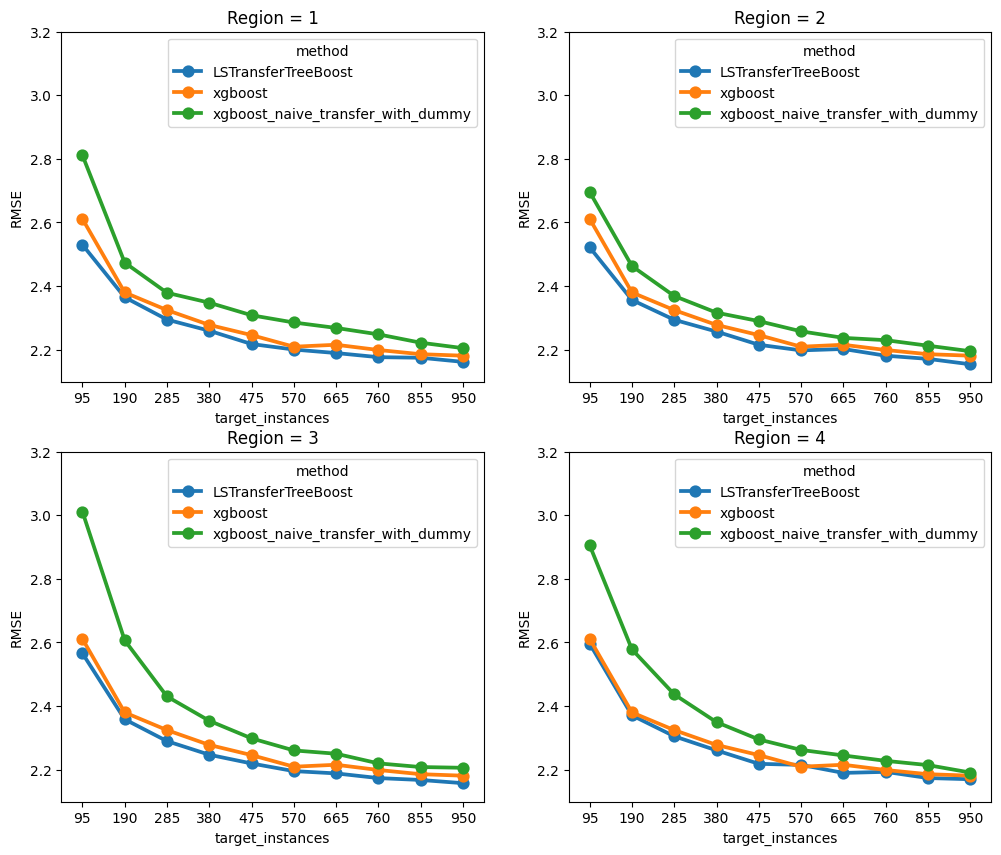

In [151]:
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_DGV_rs_{d}_250926.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
  
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_DGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs.csv')
    trada = trada.rename(columns = {'train_size_': 'target_instances'})
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=5
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    #df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)
    sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method', errorbar=None)
    plt.ylabel('RMSE')
    plt.ylim([2.1, 3.2])

    plt.title(f'Region = {d}')




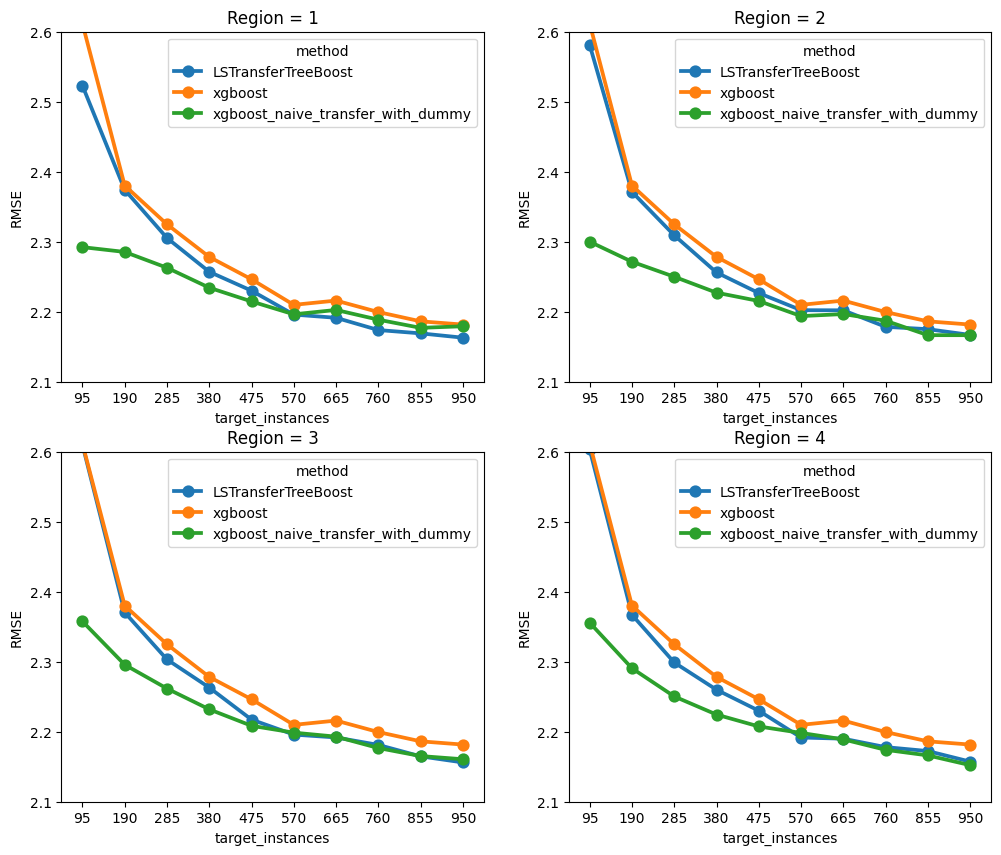

In [152]:
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_rs_{d}_250927.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
  
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_HGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs.csv')
    trada = trada.rename(columns = {'train_size_': 'target_instances'})
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=5
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    #df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)
    sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method', errorbar=None)
    plt.ylabel('RMSE')
    plt.ylim([2.1, 2.6])

    plt.title(f'Region = {d}')




In [153]:
dat

,seed,target_column,target_instances,method,v,source_tree_size,target_tree_size,k,m_0,val_rmse,val_mae,rmse,mae
414,1,Hgv,95,LSTransferTreeBoost,0.05,1,1,0.01,0.5,2.890576,2.186744,2.829071,2.130020
417,1,Hgv,95,LSTransferTreeBoost,0.05,1,1,0.01,0.9,2.858158,2.182264,2.825275,2.149825
478,1,Hgv,95,LSTransferTreeBoost,0.05,1,1,0.05,0.5,3.252354,2.472483,3.193337,2.447868
480,1,Hgv,95,LSTransferTreeBoost,0.05,1,1,0.05,0.9,3.098605,2.334320,3.044060,2.308434
482,1,Hgv,95,LSTransferTreeBoost,0.05,1,2,0.01,0.5,2.951251,2.250149,2.863031,2.177426
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,10,Hgv,950,LSTransferTreeBoost,0.10,2,1,0.05,0.9,2.254393,1.675894,2.202151,1.577033
1001,10,Hgv,950,LSTransferTreeBoost,0.10,2,2,0.01,0.5,2.250302,1.661409,2.148996,1.548399
1003,10,Hgv,950,LSTransferTreeBoost,0.10,2,2,0.01,0.9,2.244831,1.645821,2.129208,1.545651
1004,10,Hgv,950,LSTransferTreeBoost,0.10,2,2,0.05,0.5,2.257066,1.666789,2.158693,1.560073


In [154]:
best_LSTransferTreeBoost[0:10]


,target_column,target_instances,method,avg_rmse,rmse,mae
3171,Hgv,950,LSTransferTreeBoost,2.210782,2.103818,1.583164
3170,Hgv,950,LSTransferTreeBoost,2.210782,2.175795,1.549760
3173,Hgv,950,LSTransferTreeBoost,2.210782,2.152351,1.606463
3172,Hgv,950,LSTransferTreeBoost,2.210782,2.071792,1.499435
3174,Hgv,950,LSTransferTreeBoost,2.210782,2.187054,1.563615
3175,Hgv,950,LSTransferTreeBoost,2.210782,2.221174,1.630790
3177,Hgv,950,LSTransferTreeBoost,2.210782,2.167245,1.603623
3176,Hgv,950,LSTransferTreeBoost,2.210782,2.217562,1.571734
3178,Hgv,950,LSTransferTreeBoost,2.210782,2.145016,1.549727
3179,Hgv,950,LSTransferTreeBoost,2.210782,2.129208,1.545651


In [155]:
best_params_for_us

,target_column,target_instances,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,method,val_rmse,val_mae,rmse,mae
3171,Hgv,950,0.10,2,2,0.01,0.9,2.210782,1.599038,10,2,LSTransferTreeBoost,2.070221,1.492941,2.103818,1.583164
3170,Hgv,950,0.10,2,2,0.01,0.9,2.210782,1.599038,10,1,LSTransferTreeBoost,2.219475,1.590754,2.175795,1.549760
3173,Hgv,950,0.10,2,2,0.01,0.9,2.210782,1.599038,10,4,LSTransferTreeBoost,2.215551,1.614543,2.152351,1.606463
3172,Hgv,950,0.10,2,2,0.01,0.9,2.210782,1.599038,10,3,LSTransferTreeBoost,2.305243,1.645435,2.071792,1.499435
3174,Hgv,950,0.10,2,2,0.01,0.9,2.210782,1.599038,10,5,LSTransferTreeBoost,2.263831,1.652801,2.187054,1.563615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Hgv,95,0.05,2,1,0.01,0.9,2.642523,1.975908,10,2,LSTransferTreeBoost,2.267190,1.684070,2.433714,1.798624
98,Hgv,95,0.05,2,1,0.01,0.9,2.642523,1.975908,10,9,LSTransferTreeBoost,2.692075,2.015854,2.403195,1.801924
99,Hgv,95,0.05,2,1,0.01,0.9,2.642523,1.975908,10,10,LSTransferTreeBoost,2.664048,2.015724,2.605171,1.942618
92,Hgv,95,0.05,2,1,0.01,0.9,2.642523,1.975908,10,3,LSTransferTreeBoost,2.661832,1.916586,2.413417,1.745162
